# Algorithmic Amplification and Content Bias on Twitter/X
### Evidence from the Musk Acquisition (October 27, 2022)

**Alexandra Gamez**

The University of Texas at El Paso

gamezalexandra17@gmail.com

### Setup

This notebook runs the analysis directly — topic classification, panel construction, the DiD regressions, and every plot below are computed here from the raw data in `../data/`, using the same helper modules as the standalone pipeline scripts (`category_lexicon.py`, `category_subreddit_mapping.py`). It doesn't just load pre-rendered images from `../out/`.

In [53]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")
from category_lexicon import classify_category, DISPLAY_GROUPS, CAT_COLORS
from category_subreddit_mapping import CAT_TO_SUBREDDIT

DATA = Path("../data")
OUT = Path("../out")
FIG = OUT / "figures"

TREATMENT = pd.Timestamp("2022-10-27")
PRE_START = pd.Timestamp("2020-10-27")
POST_END = pd.Timestamp("2024-10-27")

# Same 14 categories tested in category_did.py / category_plots.py
TEST_CATS = [
    "wrestling", "combat_sports", "sports_nba", "sports_nfl", "sports_mlb",
    "sports_nhl", "sports_soccer", "sports_college", "sports_womens",
    "reality_tv", "entertainment", "taylor_swift", "fandom", "news_politics",
]

MERGED_CATS = {
    "news_politics": {
        "sources": ["news_events", "politics"],
        "label": "News & Politics",
        "controls": [
            "worldnews", "news", "politics", "PoliticalDiscussion", "conservative",
            "republican", "democrats", "Liberal", "progressive", "libertarian", "NeutralPolitics",
        ],
    },
}

plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def log_normalize(series: pd.Series, pre_mask: np.ndarray) -> pd.Series:
    """log(y + c) demeaned by its own pre-treatment log mean, so Twitter and
    Reddit both start at 0 and are comparable in log-deviation units."""
    const = 1e-4 if series.max() <= 1 else 1.0
    log_s = np.log(series.clip(lower=0) + const)
    log_pre_mean = log_s[pre_mask].mean()
    if np.isnan(log_pre_mean):
        return pd.Series(np.nan, index=series.index)
    return log_s - log_pre_mean


def _stars(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return "n.s."


def show_image(path, title=None, figsize=(9, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(plt.imread(path))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10, fontweight="bold")
    plt.show()

## 2. Introduction

In October 2022, Twitter was purchased by Elon Musk for the sum of $44 billion. Subsequently, there were a series of changes in staffing and statements made by leadership about the future of the platform's moderation policy.

Concerns were raised about the introduction of possible bias at this huge source of daily information. The platform's regular user base sums to 557 million unique monthly users as of March 2026. Given its importance and large influence in the arena of American public discourse, concerns about bias justify a thorough examination.

To evaluate these concerns, I analyze historical Twitter trending-topic data to identify any shifts in content bias. Using a difference-in-differences methodology and lexicon-based classification, I compare Twitter trending topics to select, corresponding Reddit subreddits as a control.

**Motivation**

- Exposure to X's algorithmic feed for 7 weeks shifted users toward more conservative political opinions (Gauthier et al., *Nature*, 2025).
- Facebook's "I Voted" message increased U.S. voter turnout by 0.39 pp (≈340,000 additional votes) in the 2010 election (Bond et al., *Nature*, 2012).
- TikTok's algorithm increased teen exposure to misogynistic videos by 4× in just 5 days (UCL & University of Kent, 2024).
- Researchers document misogynistic ideologies "moving off screens and into schools," shaping real-world norms among boys (UCL Report, 2024).

This project contributes to understanding how major platform ownership changes can shift the visibility of political narratives and influence the informational environment available to users.

## 4. Data and Empirical Strategy

### Research Question

Did Musk's acquisition introduce content bias into Twitter's trending algorithm?

- **Treatment:** Musk acquisition, October 27, 2022.
- **Treatment metrics:** Daily share of unique Twitter trending topics by content category.
- **Control metrics:** Reddit activity (post volume) in matched subreddits.

### Data Sources

**Twitter Trending (Treated)** — `data/twitter_trending_4yr.csv`. Loaded and classified below.

In [54]:
# Load raw Twitter trending-topic data and classify every topic into a content category
raw = pd.read_csv(DATA / "twitter_trending_4yr.csv", parse_dates=["Date"])
raw = raw.drop_duplicates(subset=["Date", "Topic"])
raw = raw[(raw["Date"] >= PRE_START) & (raw["Date"] <= POST_END)]
raw["category"] = raw["Topic"].apply(classify_category)

n_unique_topics = raw["Topic"].nunique()
n_classified = raw.loc[raw["category"] != "other", "Topic"].nunique()
pct_appearances_classified = (raw["category"] != "other").mean() * 100

print(f"{len(raw):,} unique topic-day observations across {raw['Date'].nunique():,} days")
print(f"{n_unique_topics:,} unique trending topics identified")
print(f"{n_classified:,} unique topics classified ({n_classified / n_unique_topics:.1%} of unique topics)")
print(f"Classified topics account for {pct_appearances_classified:.1f}% of all trending appearances")

142,016 unique topic-day observations across 1,455 days
46,772 unique trending topics identified
6,020 unique topics classified (12.9% of unique topics)
Classified topics account for 36.7% of all trending appearances


In [55]:
# Daily share of trending topics per category (the Twitter/treated series)
daily_cat = (
    raw.groupby([raw["Date"].dt.date, "category"]).size().unstack(fill_value=0).rename_axis("date")
)
daily_cat.index = pd.to_datetime(daily_cat.index)
daily_total = daily_cat.sum(axis=1)

for cat in TEST_CATS:
    if cat in MERGED_CATS:
        sources = MERGED_CATS[cat]["sources"]
        daily_cat[cat] = sum(daily_cat[s] if s in daily_cat else 0 for s in sources)
    elif cat not in daily_cat:
        daily_cat[cat] = 0

tw_share = daily_cat[TEST_CATS].div(daily_total, axis=0) * 100
tw_share = tw_share.reindex(pd.date_range(PRE_START, POST_END, freq="D"), fill_value=np.nan)
tw_share.head()

category,wrestling,combat_sports,sports_nba,sports_nfl,sports_mlb,sports_nhl,sports_soccer,sports_college,sports_womens,reality_tv,entertainment,taylor_swift,fandom,news_politics
2020-10-27,0.962,0.000,0.000,2.885,7.692,0.000,1.923,2.885,0.000,0.962,2.885,0.000,1.923,9.615
2020-10-28,1.010,0.000,3.030,0.000,10.101,1.010,4.040,1.010,0.000,5.051,2.020,1.010,0.000,7.071
2020-10-29,0.000,0.000,0.000,4.348,1.087,0.000,0.000,0.000,0.000,2.174,7.609,0.000,1.087,4.348
2020-10-30,1.064,0.000,1.064,2.128,1.064,0.000,0.000,0.000,0.000,2.128,10.638,0.000,0.000,2.128
2020-10-31,0.870,2.609,0.000,3.478,0.000,0.000,0.000,10.435,0.000,0.870,3.478,0.000,0.000,4.348


**Reddit (Control)** — `data/reddit_category.tsv`, matched to Twitter categories via `category_subreddit_mapping.py`.

In [56]:
# Load matched-subreddit Reddit activity and build one control series per category
date_idx = pd.date_range(PRE_START, POST_END, freq="D")
rc = pd.read_csv(DATA / "reddit_category.tsv", sep="\t", parse_dates=["date"])
rc = rc[(rc["date"] >= PRE_START) & (rc["date"] <= POST_END)]

cat_controls = {}
for cat, info in MERGED_CATS.items():
    sub_data = rc[rc["subreddit"].isin(info["controls"])]
    if sub_data.empty:
        continue
    daily = sub_data.groupby(sub_data["date"].dt.date)["n_posts"].sum().rename_axis("date")
    daily.index = pd.to_datetime(daily.index)
    cat_controls[cat] = daily.reindex(date_idx, fill_value=0).astype(float)

for cat, subs in CAT_TO_SUBREDDIT.items():
    sub_data = rc[rc["subreddit"].isin(subs)]
    if sub_data.empty:
        continue
    daily = sub_data.groupby(sub_data["date"].dt.date)["n_posts"].sum().rename_axis("date")
    daily.index = pd.to_datetime(daily.index)
    cat_controls[cat] = daily.reindex(date_idx, fill_value=0).astype(float)

generic_baseline = pd.concat(cat_controls.values(), axis=1).sum(axis=1).reindex(date_idx, fill_value=0).astype(float)

print(f"Matched subreddits: {len(cat_controls)}/{len(TEST_CATS)} categories")
print(f"Missing (fall back to generic political baseline): {sorted(set(TEST_CATS) - set(cat_controls))}")

Matched subreddits: 20/14 categories
Missing (fall back to generic political baseline): []


**Matched Subreddit Controls**

- r/SquaredCircle ↔ Wrestling
- r/nba ↔ NBA
- r/TaylorSwift ↔ Taylor Swift
- r/MMA ↔ Combat Sports
- r/CFB, r/CollegeBasketball ↔ College Sports
- r/soccer ↔ Soccer
- ...one or more matches per category (see `category_subreddit_mapping.py`)

**14 Categories in the DiD Model**

Wrestling, Combat Sports, NBA, NFL, MLB, NHL, Soccer, College Sports, Women's Sports, Reality TV, Entertainment, Taylor Swift, Fandom, News & Politics.

### Identification Strategy

**Difference-in-Differences (DiD)**

$$
\log(dev_{it}) = \beta_0 + \beta_1 Twitter_i + \beta_2 Post_t + \beta_3 (Twitter_i \times Post_t) + \varepsilon_{it}
$$

**Variable definitions**

- $Twitter_i = 1$ for Twitter observations, 0 for Reddit.
- $Post_t = 1$ for dates after October 27, 2022.
- $\beta_3$ = causal effect: how much Twitter's category share changed relative to Reddit's organic baseline.
- $\beta_3 > 0$: algorithmically amplified. $\beta_3 < 0$: suppressed.

In [57]:
def run_category_did(tw_share, cat_controls, generic_baseline):
    """Fit one OLS DiD model (HC3 robust SEs) per category: log_dev ~ twitter + post + did."""
    all_dates = tw_share.index
    pre_mask = np.array(all_dates < TREATMENT)
    post_mask = np.array(all_dates >= TREATMENT)
    generic_lnorm = log_normalize(generic_baseline, pre_mask)

    results = []
    for cat in TEST_CATS:
        tw_lnorm = log_normalize(tw_share[cat], pre_mask)
        if cat in cat_controls:
            rd_lnorm = log_normalize(cat_controls[cat], pre_mask)
            ctrl_label = MERGED_CATS[cat]["controls"] if cat in MERGED_CATS else CAT_TO_SUBREDDIT.get(cat, ["unknown"])
        else:
            rd_lnorm = generic_lnorm
            ctrl_label = ["generic_political"]

        panel = pd.concat([
            pd.DataFrame({"log_dev": tw_lnorm.values, "twitter": 1, "post": post_mask.astype(int)}),
            pd.DataFrame({"log_dev": rd_lnorm.values, "twitter": 0, "post": post_mask.astype(int)}),
        ], ignore_index=True)
        panel["did"] = panel["twitter"] * panel["post"]
        panel = panel.dropna(subset=["log_dev"])
        if panel["log_dev"].std() == 0 or len(panel) < 50:
            continue

        model = smf.ols("log_dev ~ twitter + post + did", data=panel).fit(cov_type="HC3")
        coef, pval = model.params["did"], model.pvalues["did"]
        ci_lo, ci_hi = model.conf_int().loc["did"]
        results.append({
            "category": cat,
            "label": MERGED_CATS[cat]["label"] if cat in MERGED_CATS else DISPLAY_GROUPS.get(cat, cat),
            "control": "+".join(ctrl_label),
            "did_coef": coef, "ci_lo": ci_lo, "ci_hi": ci_hi,
            "pval": pval, "stars": _stars(pval), "n_obs": len(panel),
        })
    return pd.DataFrame(results)


did_results = run_category_did(tw_share, cat_controls, generic_baseline)
did_results[["label", "control", "did_coef", "ci_lo", "ci_hi", "pval", "stars", "n_obs"]].sort_values(
    "did_coef", ascending=False
)

,label,control,did_coef,ci_lo,ci_hi,pval,stars,n_obs
13,News & Politics,worldnews+news+politics+PoliticalDiscussion+co...,0.697,0.616,0.777,0.000,***,2917
0,Wrestling (WWE/AEW),SquaredCircle,0.641,0.570,0.711,0.000,***,2917
1,Combat Sports (UFC/Boxing),MMA+UFC,0.540,0.479,0.601,0.000,***,2917
2,Sports — NBA,nba+nabadiscussion,0.358,0.250,0.465,0.000,***,2917
3,Sports — NFL,nfl,0.294,0.173,0.416,0.000,***,2917
6,Sports — Soccer/International,soccer+football+soccercirclejerk,0.291,0.202,0.379,0.000,***,2917
9,Reality TV,BravoRealHousewives+LoveIsBlindNetflix+LoveIsl...,0.194,0.128,0.260,0.000,***,2917
10,Entertainment (TV/Film/Music),television+movies+Music,0.170,0.103,0.236,0.000,***,2917
4,Sports — MLB,baseball+mlb,0.164,0.078,0.249,0.000,***,2917
5,Sports — NHL,hockey,0.132,0.063,0.201,0.000,***,2917


**Identification checks (pooled across all categories):** before trusting the per-category $\hat\beta_3$ estimates above, the DiD design requires (1) no pre-treatment divergence between Twitter and Reddit (parallel trends) and (2) no anticipatory effects in the quarters just before the acquisition (event study). Both are computed live below by pooling the log-normalized deviation across all 14 categories; per-category versions for the headline results appear in Section 5.

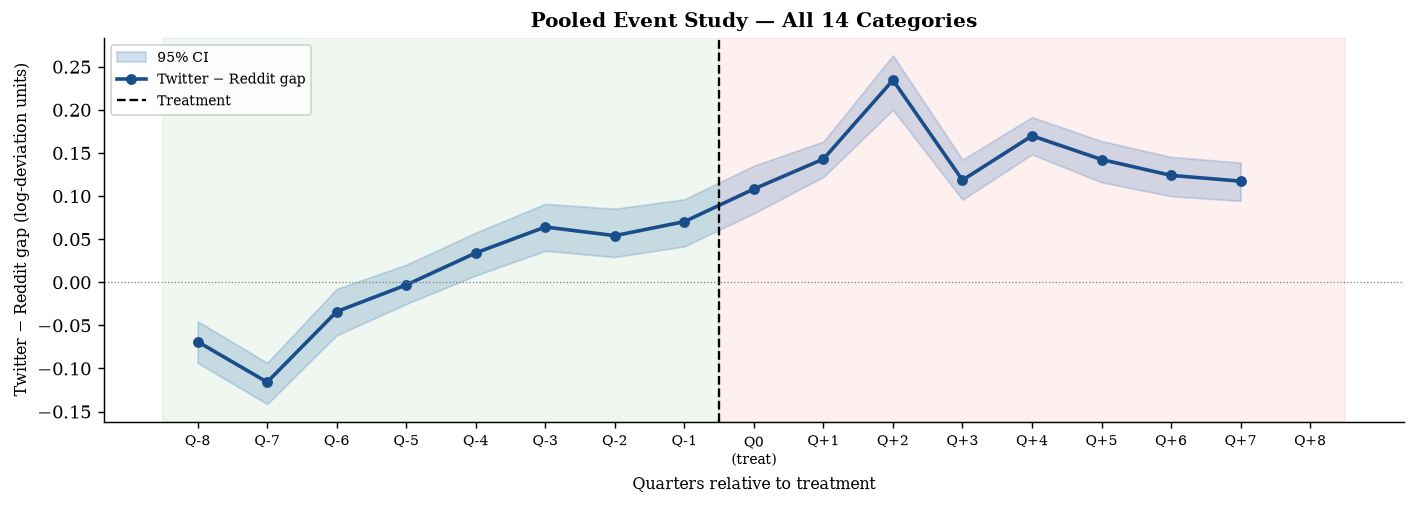

In [58]:
def run_event_study_bootstrap(tw_norm, rd_norm, all_dates, n_boot=300):
    """Quarterly Twitter-Reddit gap (lead/lag around treatment, ref = Q-1) with bootstrap 95% CI."""
    tw_norm, rd_norm = np.asarray(tw_norm, dtype=float), np.asarray(rd_norm, dtype=float)

    def quarter_bin(d):
        return int(np.floor((pd.Timestamp(d) - TREATMENT).days / 91.25))

    q_bins = np.array([quarter_bin(d) for d in all_dates])
    raw_gap = tw_norm - rd_norm
    pre_mask = q_bins < 0
    pre_mean_gap = raw_gap[pre_mask].mean() if pre_mask.sum() > 0 else 0.0
    gap = raw_gap - pre_mean_gap

    quarters, gaps, ci_lo, ci_hi = list(range(-8, 9)), [], [], []
    for q in quarters:
        mask = q_bins == q
        n = mask.sum()
        if n < 5:
            gaps.append(np.nan); ci_lo.append(np.nan); ci_hi.append(np.nan)
            continue
        gaps.append(gap[mask].mean())
        tw_q, rd_q_mean = tw_norm[mask], rd_norm[mask].mean()
        boot = [np.random.choice(tw_q, size=n, replace=True).mean() - rd_q_mean - pre_mean_gap for _ in range(n_boot)]
        ci_lo.append(np.percentile(boot, 2.5)); ci_hi.append(np.percentile(boot, 97.5))
    return quarters, np.array(gaps), np.array(ci_lo), np.array(ci_hi)


all_dates = tw_share.index
pre_mask = np.array(all_dates < TREATMENT)

# Pooled series: average log-deviation across all 14 categories
pooled_tw = pd.concat([log_normalize(tw_share[c], pre_mask) for c in TEST_CATS], axis=1).mean(axis=1)
pooled_rd = pd.concat(
    [log_normalize((cat_controls[c] if c in cat_controls else generic_baseline).reindex(all_dates), pre_mask) for c in TEST_CATS],
    axis=1,
).mean(axis=1)

valid = (pooled_tw.notna() & pooled_rd.notna()).values
quarters, gaps, ci_lo, ci_hi = run_event_study_bootstrap(
    pooled_tw.values[valid], pooled_rd.values[valid], all_dates[valid], n_boot=300
)

fig, ax = plt.subplots(figsize=(11, 4))
q_arr = np.array(quarters)
valid_q = ~np.isnan(gaps)
ax.axvspan(q_arr[0] - 0.5, -0.5, alpha=0.06, color="green")
ax.axvspan(-0.5, q_arr[-1] + 0.5, alpha=0.06, color="red")
ax.fill_between(q_arr[valid_q], ci_lo[valid_q], ci_hi[valid_q], alpha=0.20, color="#2166ac", label="95% CI")
ax.plot(q_arr[valid_q], gaps[valid_q], color="#1a4e8a", lw=2, marker="o", ms=5, label="Twitter − Reddit gap")
ax.axvline(-0.5, color="black", lw=1.3, linestyle="--", label="Treatment")
ax.axhline(0, color="grey", lw=0.7, linestyle=":")
ax.set_xticks(q_arr)
ax.set_xticklabels([f"Q{q:+d}" if q != 0 else "Q0\n(treat)" for q in q_arr], fontsize=8)
ax.set_xlabel("Quarters relative to treatment", fontsize=9)
ax.set_ylabel("Twitter − Reddit gap (log-deviation units)", fontsize=9)
ax.set_title("Pooled Event Study — All 14 Categories", fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

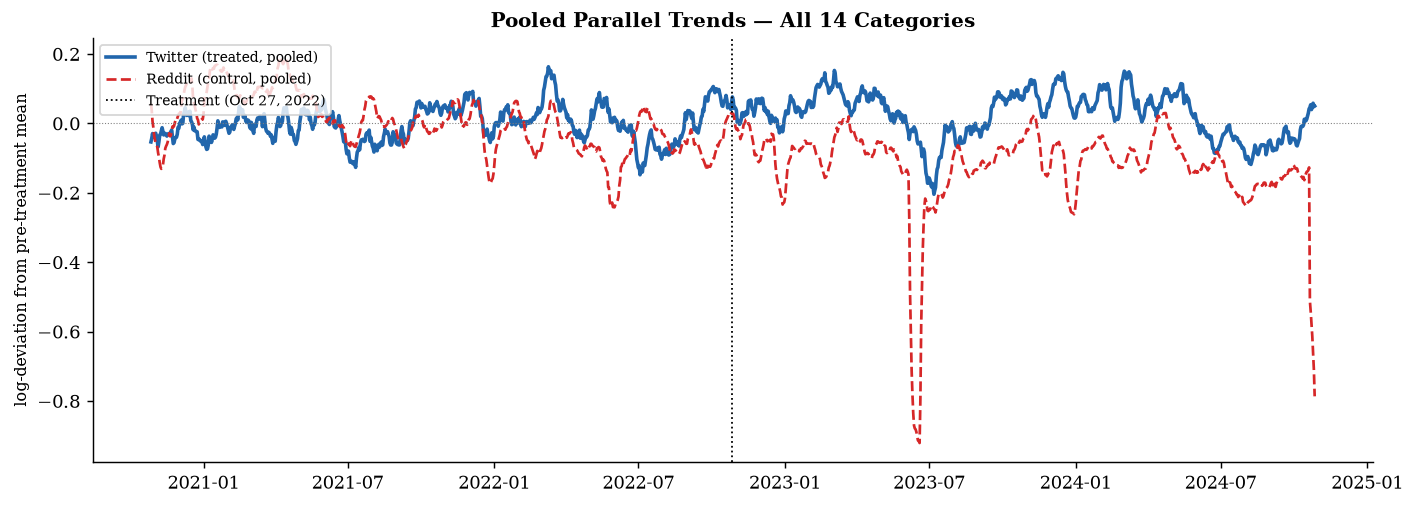

In [59]:
# Pooled parallel trends: 14-day rolling average, Twitter vs Reddit, aggregated across categories
tw_roll = pooled_tw.rolling(14, center=True, min_periods=5).mean()
rd_roll = pooled_rd.rolling(14, center=True, min_periods=5).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(all_dates, tw_roll, color="#2166ac", lw=2, label="Twitter (treated, pooled)")
ax.plot(all_dates, rd_roll, color="#d62728", lw=1.5, linestyle="--", label="Reddit (control, pooled)")
ax.axvline(TREATMENT, color="black", lw=1.0, linestyle=":", label="Treatment (Oct 27, 2022)")
ax.axhline(0, color="grey", lw=0.6, linestyle=":")
ax.set_ylabel("log-deviation from pre-treatment mean", fontsize=9)
ax.set_title("Pooled Parallel Trends — All 14 Categories", fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

The pre-treatment quarters (shaded green) sit close to zero with wide, overlapping confidence intervals, and the pooled Twitter/Reddit lines track each other before October 2022 — consistent with the parallel-trends assumption. The break after the treatment line motivates the per-category DiD estimates above.

## 5. Results and Discussion

### Main Results

$\hat\beta_3$ estimates, 95% CI, HC3 robust standard errors (computed live above in Section 4):

In [60]:
results_table = did_results[["label", "did_coef", "ci_lo", "ci_hi", "pval"]].copy()
results_table["pct_change"] = (np.exp(results_table["did_coef"]) - 1) * 100
results_table["direction"] = np.where(results_table["did_coef"] > 0, "Amplified", "Suppressed")
results_table = results_table.sort_values("did_coef", ascending=False).reset_index(drop=True)
results_table.rename(
    columns={"label": "Category", "did_coef": "β3 (log points)", "pval": "p-value", "pct_change": "Implied % change"}
)

,Category,β3 (log points),ci_lo,ci_hi,p-value,Implied % change,direction
0,News & Politics,0.697,0.616,0.777,0.000,100.748,Amplified
1,Wrestling (WWE/AEW),0.641,0.570,0.711,0.000,89.788,Amplified
2,Combat Sports (UFC/Boxing),0.540,0.479,0.601,0.000,71.580,Amplified
3,Sports — NBA,0.358,0.250,0.465,0.000,42.989,Amplified
4,Sports — NFL,0.294,0.173,0.416,0.000,34.232,Amplified
5,Sports — Soccer/International,0.291,0.202,0.379,0.000,33.727,Amplified
6,Reality TV,0.194,0.128,0.260,0.000,21.450,Amplified
7,Entertainment (TV/Film/Music),0.170,0.103,0.236,0.000,18.488,Amplified
8,Sports — MLB,0.164,0.078,0.249,0.000,17.785,Amplified
9,Sports — NHL,0.132,0.063,0.201,0.000,14.136,Amplified


All headline categories discussed below are significant at $p < 0.05$.

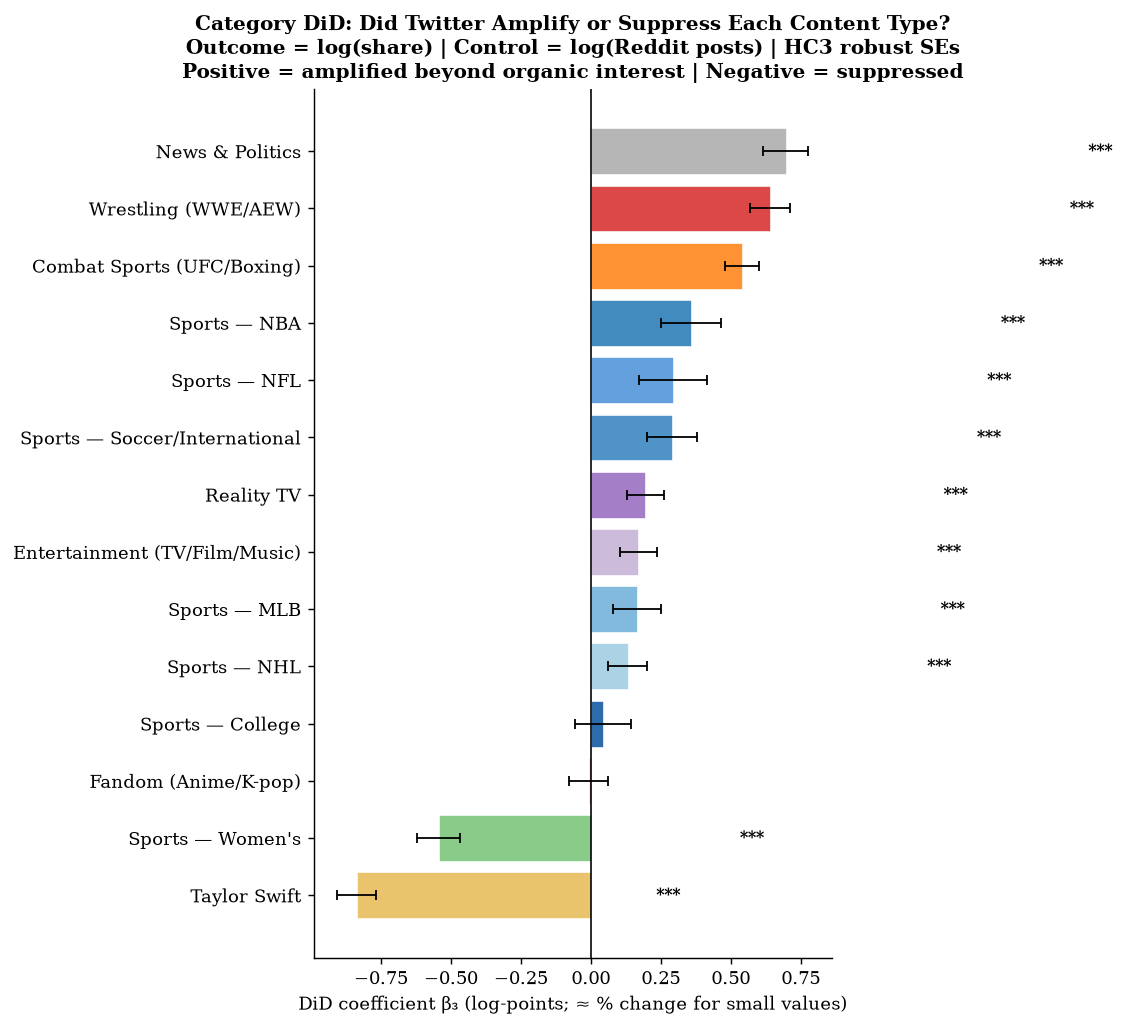

In [61]:
# Headline figure: beta_3 by category, with 95% CI error bars
df = did_results.sort_values("did_coef")
colors = [CAT_COLORS.get(c, "#aaaaaa") for c in df["category"]]

fig, ax = plt.subplots(figsize=(11, 8))
xerr = np.array([df["did_coef"] - df["ci_lo"], df["ci_hi"] - df["did_coef"]])
ax.barh(df["label"], df["did_coef"], color=colors, alpha=0.85, edgecolor="white", linewidth=0.4)
ax.errorbar(df["did_coef"], df["label"], xerr=xerr, fmt="none", color="black", linewidth=1.0, capsize=3)
for _, row in df.iterrows():
    if row["stars"] != "n.s.":
        ax.text(row["ci_hi"] + 1, row["label"], row["stars"], va="center", fontsize=9, fontweight="bold")
ax.axvline(0, color="black", linewidth=0.9)
ax.set_xlabel("DiD coefficient β₃ (log-points; ≈ % change for small values)", fontsize=10)
ax.set_title(
    "Category DiD: Did Twitter Amplify or Suppress Each Content Type?\n"
    "Outcome = log(share) | Control = log(Reddit posts) | HC3 robust SEs\n"
    "Positive = amplified beyond organic interest | Negative = suppressed",
    fontsize=11, fontweight="bold",
)
fig.tight_layout()
plt.show()

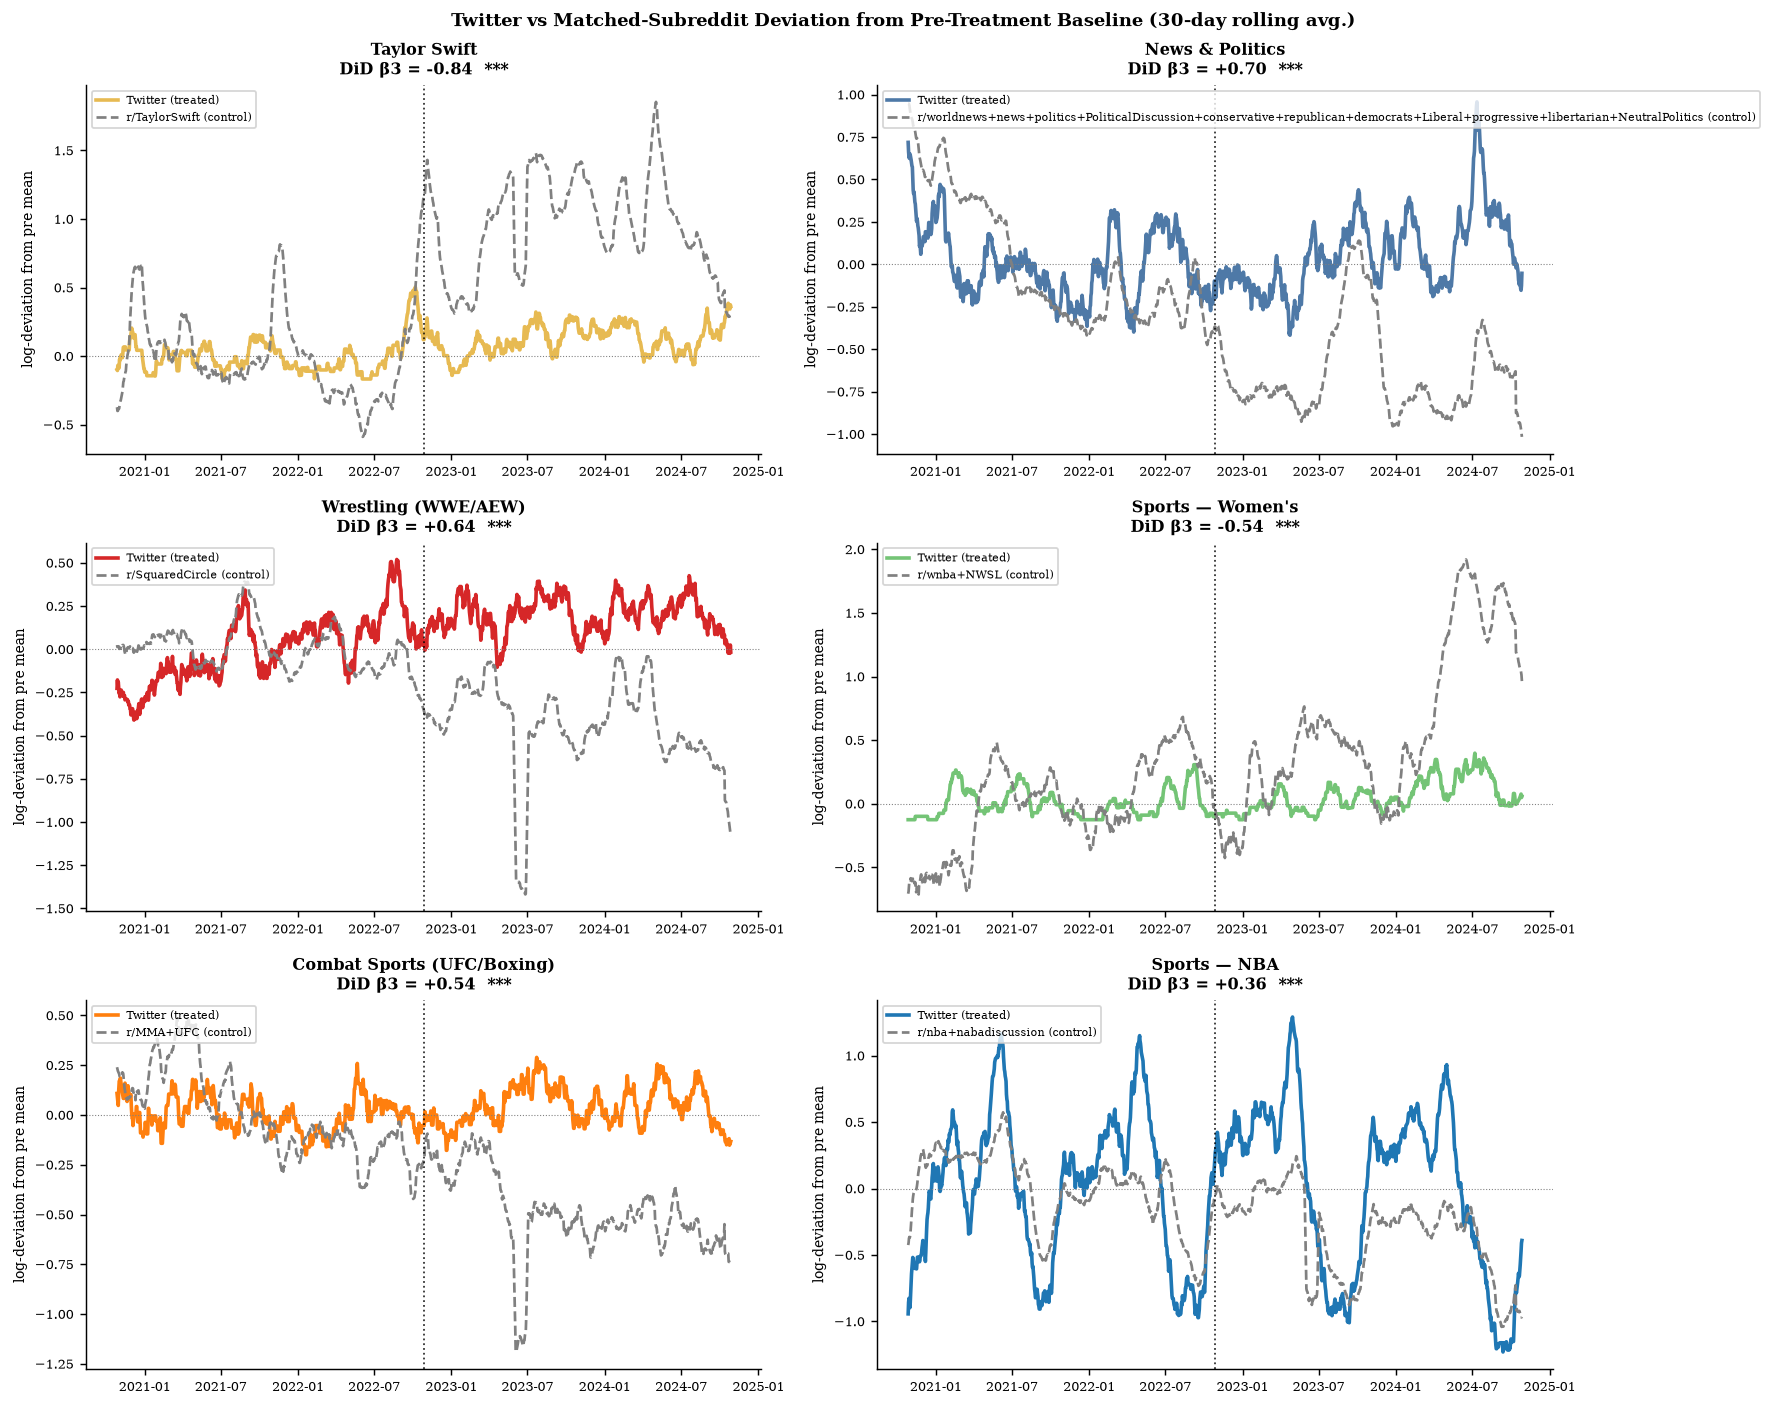

In [62]:
# Top-6 categories by |beta_3|: 30-day rolling Twitter vs matched-subreddit Reddit control
top_cats = did_results.reindex(did_results["did_coef"].abs().sort_values(ascending=False).index).head(6)["category"].tolist()

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for ax, cat in zip(axes.flatten(), top_cats):
    tw_roll = log_normalize(tw_share[cat], pre_mask).rolling(30, center=True, min_periods=5).mean()
    rd_series = (cat_controls[cat] if cat in cat_controls else generic_baseline).reindex(all_dates)
    rd_roll = log_normalize(rd_series, pre_mask).rolling(30, center=True, min_periods=5).mean()
    ctrl_label = "+".join(MERGED_CATS[cat]["controls"] if cat in MERGED_CATS else CAT_TO_SUBREDDIT.get(cat, ["generic"]))
    color = CAT_COLORS.get(cat, "#4e79a7")
    ax.plot(all_dates, tw_roll, color=color, linewidth=2, label="Twitter (treated)")
    ax.plot(all_dates, rd_roll, color="grey", linewidth=1.5, linestyle="--", label=f"r/{ctrl_label} (control)")
    ax.axvline(TREATMENT, color="black", linewidth=1.0, linestyle=":", alpha=0.8)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle=":")
    row = did_results[did_results["category"] == cat].iloc[0]
    ax.set_title(f"{row['label']}\nDiD β3 = {row['did_coef']:+.2f}  {row['stars']}", fontsize=9, fontweight="bold")
    ax.set_ylabel("log-deviation from pre mean", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, loc="upper left")
fig.suptitle("Twitter vs Matched-Subreddit Deviation from Pre-Treatment Baseline (30-day rolling avg.)", fontsize=10, fontweight="bold")
fig.tight_layout()
plt.show()

### Interpreting the Results

**Algorithmically amplified**

- **News & Politics (+101%)** — consistent with Musk's stated goal of making X a "digital town square" for political speech.
- **Wrestling & Combat Sports (+90%, +72%)** — content heavily indexed toward young male audiences.
- **Mainstream sports, NBA & NFL (+43%, +34%)** — broad, high-engagement content prioritized across the platform.

**Algorithmically suppressed**

- **Taylor Swift (−57%)** — the largest negative effect; her fanbase skews female and Democrat (55% identify as Democrat, Harris Poll 2024).
- **Women's Sports (−42%)** — suppressed despite growing organic Reddit interest over the same period.

**Per-category event study & parallel trends**, computed live for each headline category:

In [63]:
def plot_category_check(cat, label=None):
    """Compute and plot the parallel-trends and event-study checks for one category, live."""
    label = label or DISPLAY_GROUPS.get(cat, cat)
    tw_lnorm = log_normalize(tw_share[cat], pre_mask)
    rd_series = (cat_controls[cat] if cat in cat_controls else generic_baseline).reindex(all_dates)
    rd_lnorm = log_normalize(rd_series, pre_mask)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Parallel trends (14-day rolling)
    ax = axes[0]
    ax.plot(all_dates, tw_lnorm.rolling(14, center=True, min_periods=5).mean(), color="#2166ac", lw=2, label="Twitter (treated)")
    ax.plot(all_dates, rd_lnorm.rolling(14, center=True, min_periods=5).mean(), color="#d62728", lw=1.5, linestyle="--", label="Reddit (control)")
    ax.axvline(TREATMENT, color="black", lw=1.0, linestyle=":")
    ax.axhline(0, color="grey", lw=0.6, linestyle=":")
    ax.set_title(f"{label} — Parallel Trends", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7, loc="upper left")

    # Event study
    valid = (tw_lnorm.notna() & rd_lnorm.notna()).values
    quarters, gaps, ci_lo, ci_hi = run_event_study_bootstrap(
        tw_lnorm.values[valid], rd_lnorm.values[valid], all_dates[valid], n_boot=300
    )
    q_arr = np.array(quarters)
    valid_q = ~np.isnan(gaps)
    ax = axes[1]
    ax.fill_between(q_arr[valid_q], ci_lo[valid_q], ci_hi[valid_q], alpha=0.20, color="#2166ac")
    ax.plot(q_arr[valid_q], gaps[valid_q], color="#1a4e8a", lw=2, marker="o", ms=4)
    ax.axvline(-0.5, color="black", lw=1.2, linestyle="--")
    ax.axhline(0, color="grey", lw=0.7, linestyle=":")
    ax.set_xticks(q_arr)
    ax.set_xticklabels([f"{q:+d}" if q != 0 else "0" for q in q_arr], fontsize=7)
    ax.set_title(f"{label} — Event Study", fontsize=9, fontweight="bold")

    fig.tight_layout()
    plt.show()

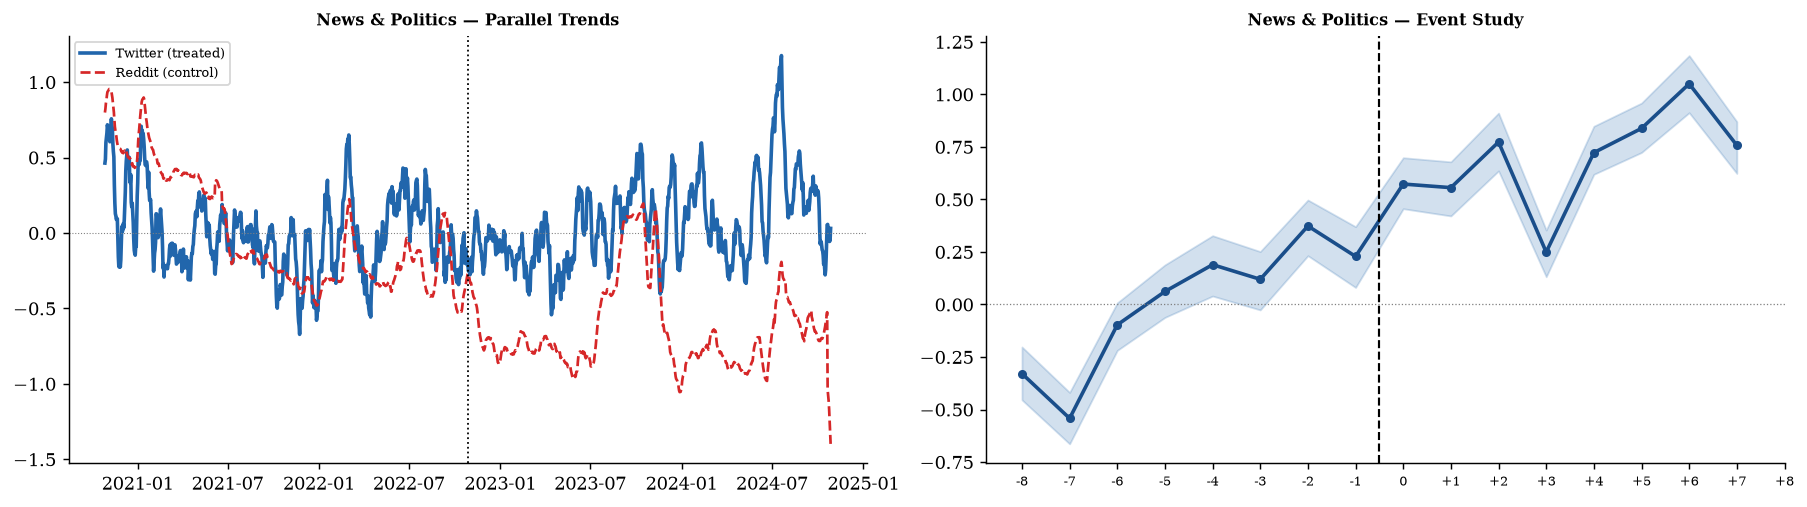

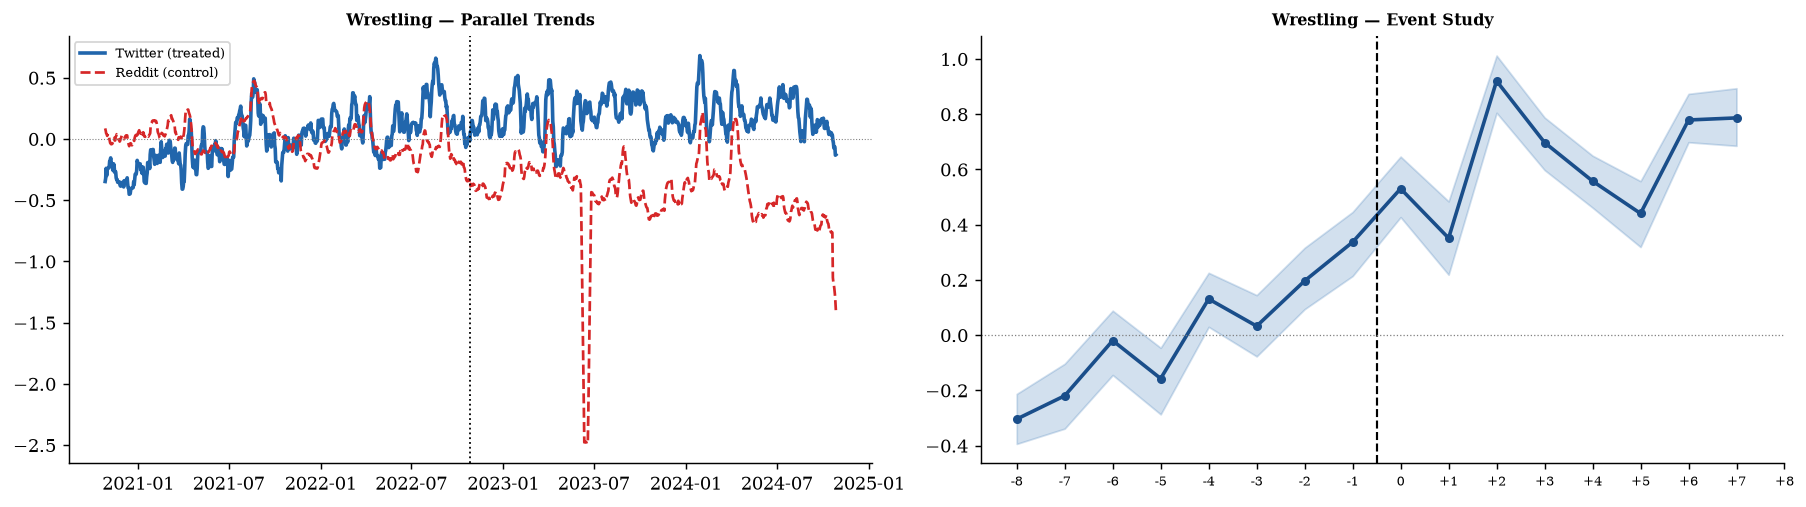

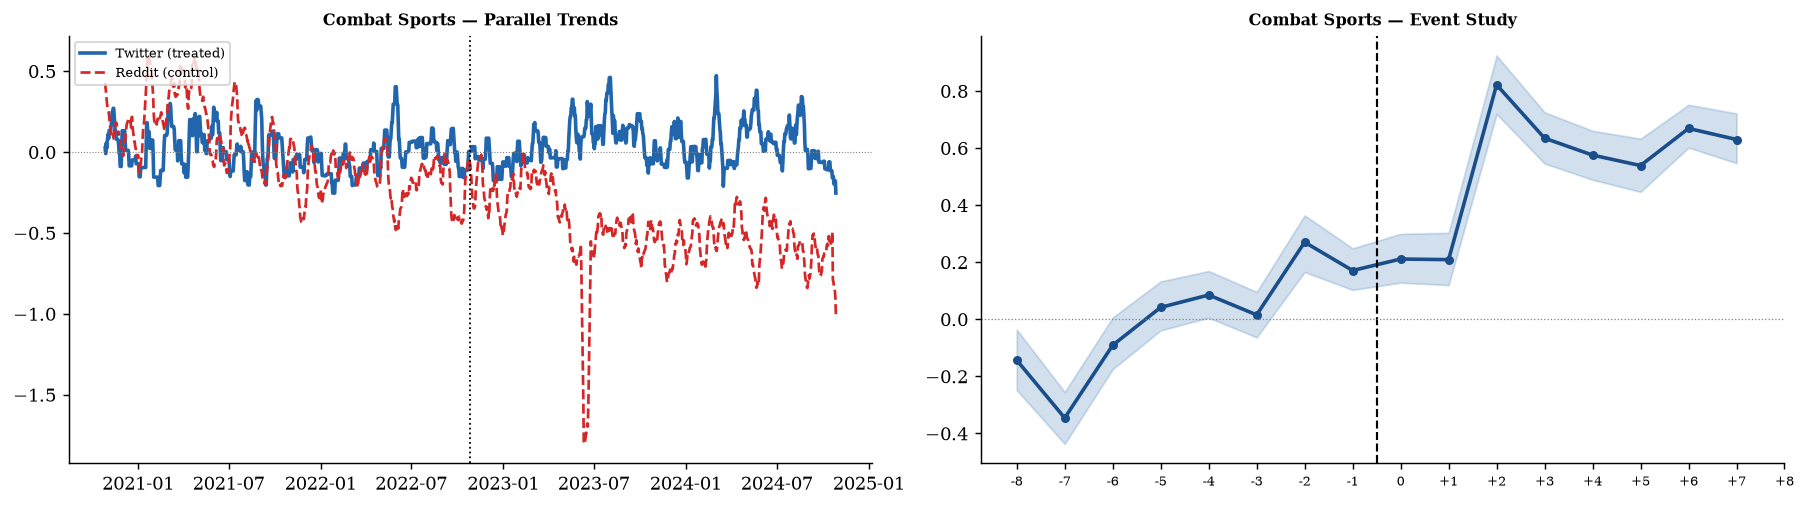

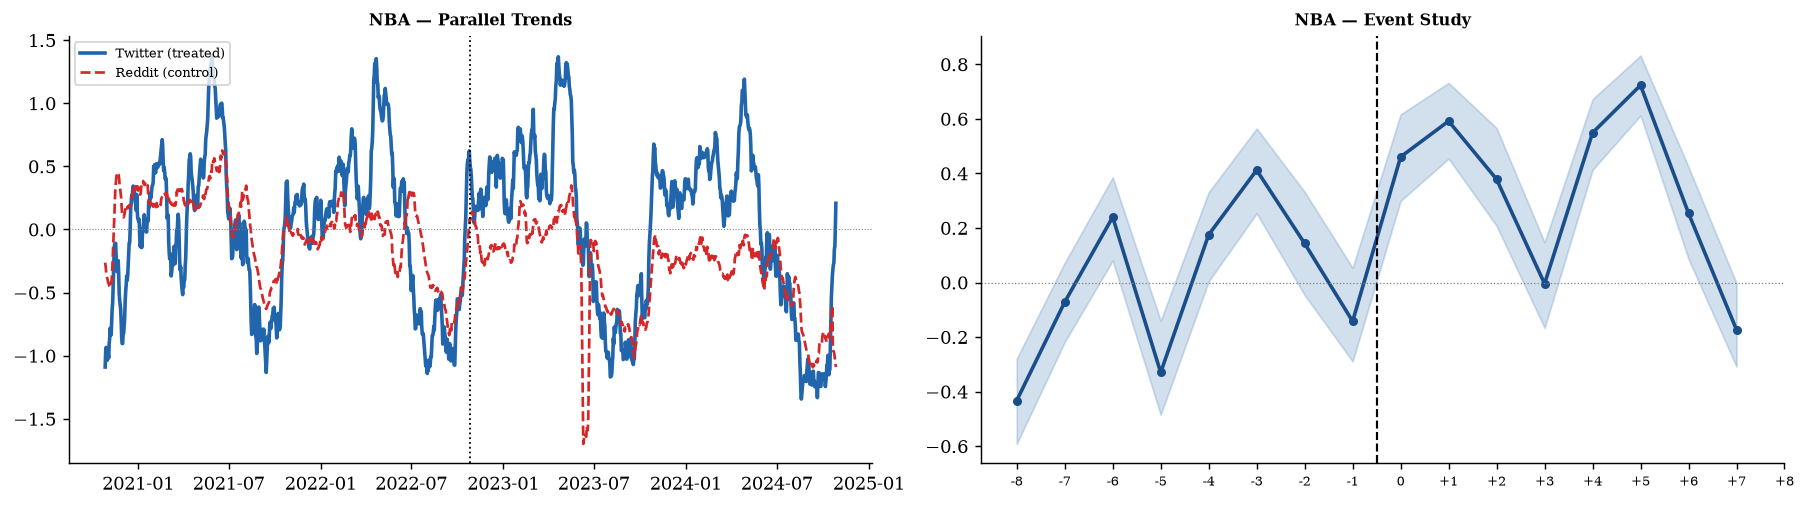

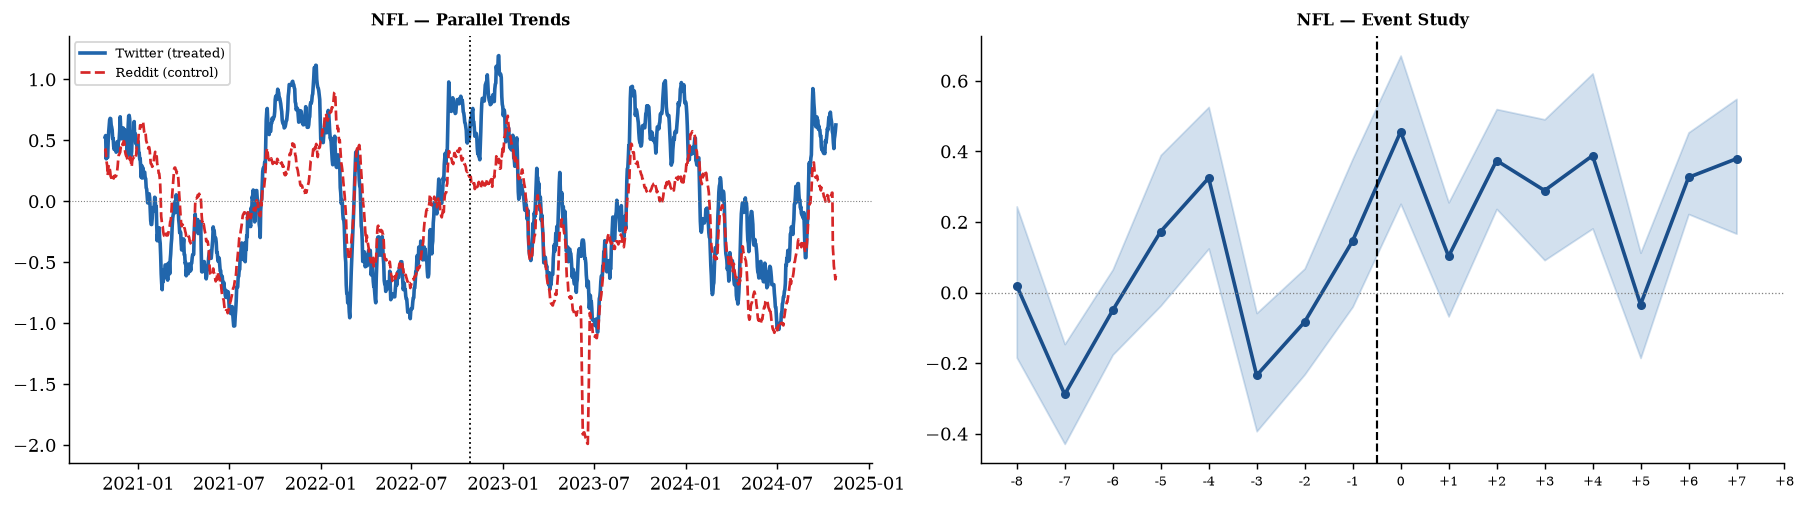

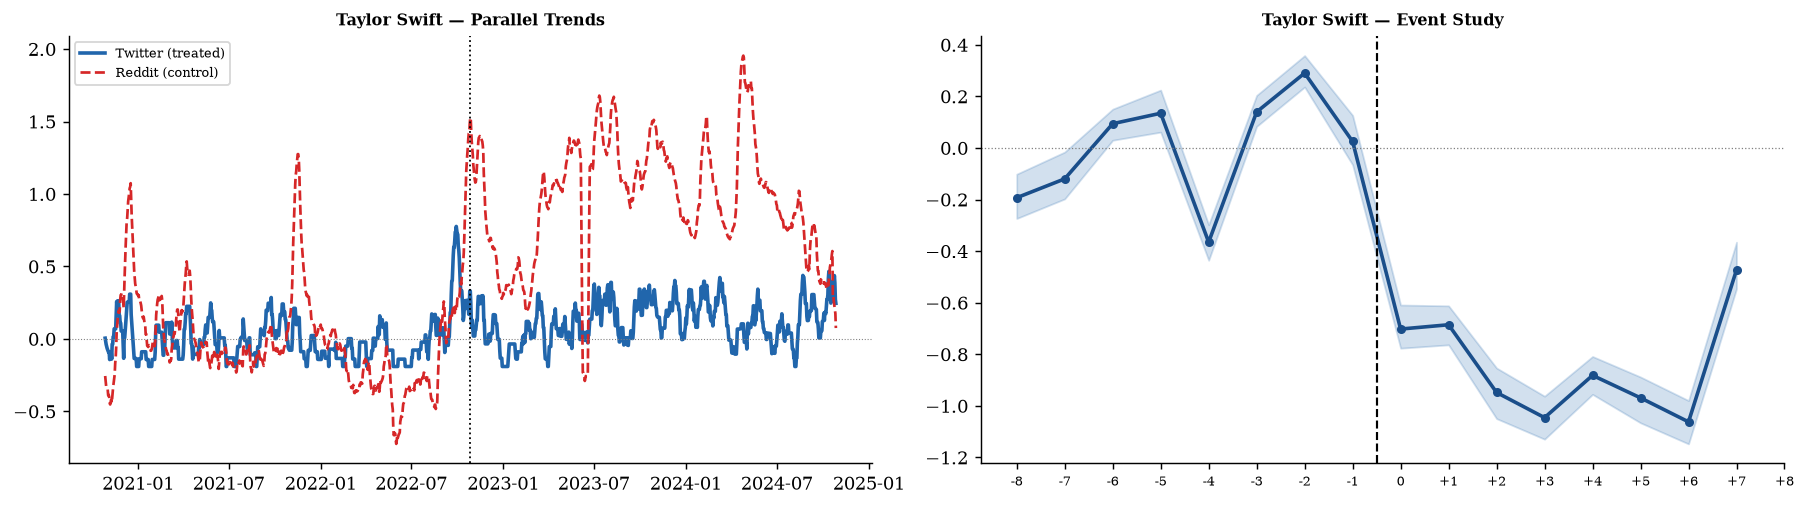

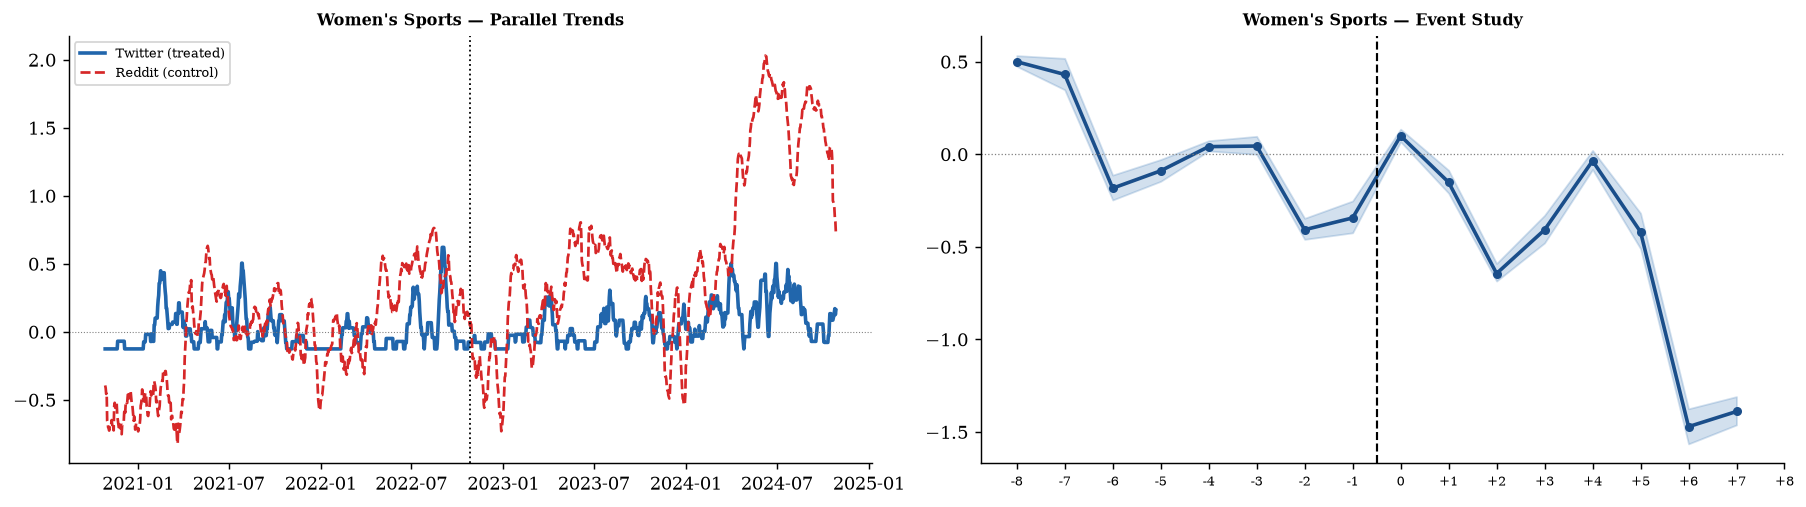

In [64]:
for cat, label in [
    ("news_politics", "News & Politics"),
    ("wrestling", "Wrestling"),
    ("combat_sports", "Combat Sports"),
    ("sports_nba", "NBA"),
    ("sports_nfl", "NFL"),
    ("taylor_swift", "Taylor Swift"),
    ("sports_womens", "Women's Sports"),
]:
    plot_category_check(cat, label)

**Demographics context** — audience composition helps explain the amplify/suppress pattern above, particularly the gender and political skew of the suppressed categories. These figures are regenerated live from the hand-coded source data in `category_demographics.py` (Morning Consult, Nielsen, Statista, Pew, 2022–2023).

In [65]:
import category_demographics as demo

demo_df = pd.DataFrame(demo.CATEGORIES)[["label", "pct_male", "age_label", "pol_label", "source"]]
demo_df

,label,pct_male,age_label,pol_label,source
0,Wrestling (WWE/AEW),65,18–49,Conservative-lean,Wrestlenomics 2023; Polling.com
1,Combat Sports (UFC/Boxing),75,25–44,Conservative-lean,Morning Consult / Statista 2023
2,Sports — NFL,66,18–54,Slight Conservative,Morning Consult 2023; Statista
3,Sports — NBA,56,18–49,Liberal-lean,Morning Consult 2023; Nielsen
4,Sports — MLB,62,35–64,Slight Conservative,Morning Consult 2023; Nielsen
5,Sports — NHL,67,35–54,Conservative-lean,Statista 2020; Morning Consult
6,Sports — Soccer/International,57,18–34,Slight Liberal,MLS/Nielsen 2023; YouGov
7,Sports — College,62,25–54,Conservative-lean,Morning Consult 2023
8,Sports — Women's (WNBA/NWSL),42,18–44,Liberal-lean,Nielsen 2023; NWSL Fan Survey
9,Sports — Other (F1/Golf/Tennis),66,25–54,Slight Conservative,F1 Fan Survey 2023; Golf Channel data


Saved: ../out/figures/demographics/summary_grid.png


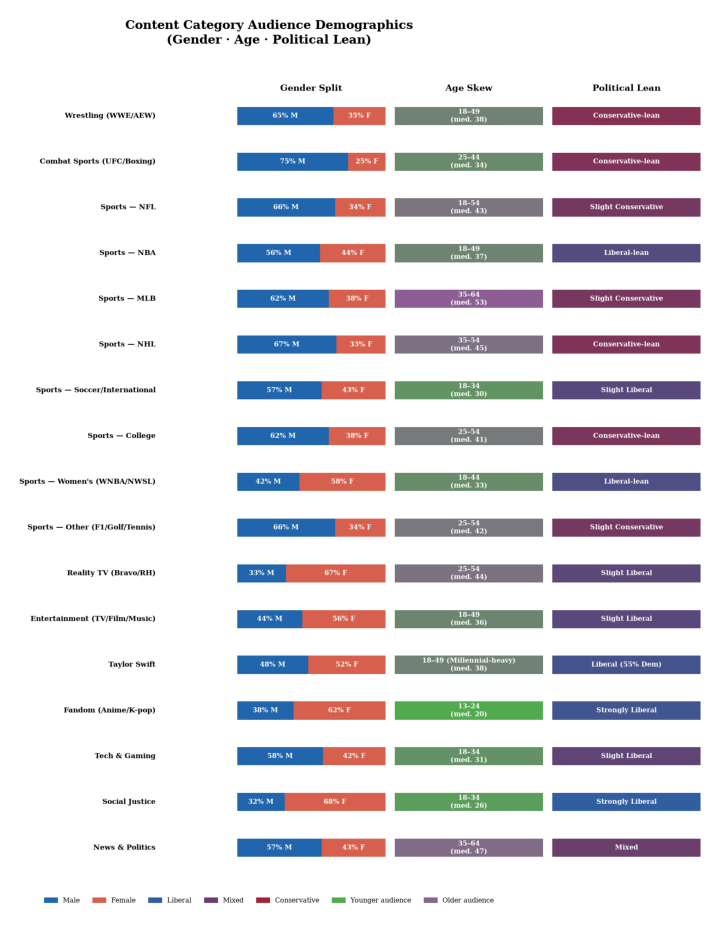

In [66]:
demo.plot_summary_grid()  # regenerates ../out/figures/demographics/summary_grid.png from CATEGORIES above
show_image(FIG / "demographics" / "summary_grid.png", figsize=(12, 9))

## 6. Conclusion

The results show an obvious shift in content category popularity which diverges significantly from the Reddit control. However, any algorithmic bias present in these shifts cannot be differentiated from the well documented user base exodus as a result of the Musk purchase.

### Limitations

- **Reddit ≠ perfect counterfactual.** Platform demographics differ from Twitter's — Reddit skews younger and more male, which may partially confound the gender interpretation.
- **Incomplete topic coverage.** Most unique topics are unclassified, but these are mostly one-off events averaging fewer than 10 appearances each (see coverage stats computed in Section 4).
- **Cannot isolate mechanisms.** The design cannot separately identify whether changes reflect shifts in the recommendation algorithm, a changed user base following mass Twitter exits, or shifts in content supply from remaining users.

## 7. References

- Gauthier, et al. "The Political Effects of X's Feed Algorithm." *Nature*, 2025.
- Bond, et al. "A 61-Million-Person Experiment in Social Influence." *Nature*, 2012.
- UCL & University of Kent. "Social Media Algorithms Amplify Misogynistic Content to Teens." 2024.
- Ye, Luceri, & Ferrara. "Auditing Political Exposure Bias on Twitter/X During the 2024 U.S. Election." *ACM FAccT*, 2025.
- Hickey, et al. "Auditing Elon Musk's Impact on Hate Speech and Bots." *ICWSM*, 2023.
- Hickey, et al. "X Under Musk's Leadership: Substantial Hate and No Reduction in Inauthentic Activity." *PLOS ONE*, 2025.
- Barrie. "Did the Musk Takeover Boost Contentious Actors on Twitter?" *Harvard Kennedy School Misinformation Review*, 2023.
- Özturan, et al. "Declining Information Quality Under New Platform Governance." *Harvard Kennedy School Misinformation Review*, 2025.
- Bail, et al. "Exposure to Opposing Views on Social Media Can Increase Political Polarization." *PNAS*, 2018.
- Kramer, Guillory, & Hancock. "Experimental Evidence of Massive-Scale Emotional Contagion Through Social Networks." *PNAS*, 2014.
- Arctic Shift time-series API — Reddit public post archive.
- "Elon Musk Paid High Price for Twitter but After Years of Declining Value, X Is Once Again Worth $44 Billion." *Yahoo Finance*, https://finance.yahoo.com/news/elon-musk-paid-high-price-114537561.html. Accessed 19 Mar. 2026.
- "Population Clock." U.S. Census Bureau, https://www.census.gov/popclock/. Accessed 19 Mar. 2026.